In [ ]:
import os

# Force single-threaded execution for deterministic results
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import random
import scanpy as sc

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
sc.settings.seed = 42

# === INPUT PATHS ===
input_folder = "/home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses/"
file_name_list_csv_input_path = "/home/ajarrah/PhD_Thesis/chapter_2/csv_data/file_name_list.csv"
filtered_h5ad_output_folder = "/home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filtered/"

In [30]:
# Read file names from CSV
file_name_df = pd.read_csv(file_name_list_csv_input_path)
file_names = file_name_df["file_name"].tolist()

In [31]:

# Create mapping from file name → short name
file_name_dict = {}
for fn in file_names:
    parts = fn.split("_")
    group = parts[0][0]         # First letter of AFM/YFM
    condition = parts[1]        # AD or C
    sample_num = parts[2]       # Sample number
    short_name = f"{group}{condition}_{sample_num}"
    file_name_dict[fn] = short_name

In [32]:
# Your list of sample IDs (also used as keys in the dictionary)
aad_1 = sc.read_h5ad(os.path.join(input_folder, "AFM_AD_1_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
aad_2 = sc.read_h5ad(os.path.join(input_folder, "AFM_AD_2_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
aad_3 = sc.read_h5ad(os.path.join(input_folder, "AFM_AD_3_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
aad_4 = sc.read_h5ad(os.path.join(input_folder, "AFM_AD_4_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
ac_1 = sc.read_h5ad(os.path.join(input_folder, "AFM_C_1_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
ac_2 = sc.read_h5ad(os.path.join(input_folder, "AFM_C_2_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
ac_3 = sc.read_h5ad(os.path.join(input_folder, "AFM_C_3_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
ac_4 = sc.read_h5ad(os.path.join(input_folder, "AFM_C_4_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
yad_1 = sc.read_h5ad(os.path.join(input_folder, "YFM_AD_1_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
yad_2 = sc.read_h5ad(os.path.join(input_folder, "YFM_AD_2_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
yad_3 = sc.read_h5ad(os.path.join(input_folder, "YFM_AD_3_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
yad_4 = sc.read_h5ad(os.path.join(input_folder, "YFM_AD_4_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
yc_1 = sc.read_h5ad(os.path.join(input_folder, "YFM_C_1_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
yc_2 = sc.read_h5ad(os.path.join(input_folder, "YFM_C_2_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
yc_3 = sc.read_h5ad(os.path.join(input_folder, "YFM_C_3_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
yc_4 = sc.read_h5ad(os.path.join(input_folder, "YFM_C_4_peaks_0.00001_top1000_9w_3p_5points.h5ad"))


In [33]:
sample_list = [
    yc_1, yc_2, yc_3, yc_4,
    yad_1, yad_2, yad_3, yad_4,
    ac_1, ac_2, ac_3, ac_4,
    aad_1, aad_2, aad_3, aad_4
]

sample_ids = [
    "yc_1", "yc_2", "yc_3", "yc_4",
    "yad_1", "yad_2", "yad_3", "yad_4",
    "ac_1", "ac_2", "ac_3", "ac_4",
    "aad_1", "aad_2", "aad_3", "aad_4"
]

# Map sample ID → AnnData object
sample_map = dict(zip(sample_ids, sample_list))


In [34]:
for adata in sample_list:
    # preprocess
    sc.pp.normalize_total(adata, target_sum=1e6)
    sc.pp.log1p(adata)
    sc.pp.scale(adata, max_value=10)

    # dimension reduction first
    sc.tl.pca(adata, n_comps=50, random_state=42, svd_solver="arpack")

    # then neighbors on PCA
    # Before running leiden, also fix the neighbors step:
    sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30, random_state=42)
    sc.tl.leiden(
        adata,
        key_added="leiden_res_0.02",
        flavor="igraph",
        resolution=0.03,
        n_iterations=2,
        random_state=42  # Fix the seed
    )


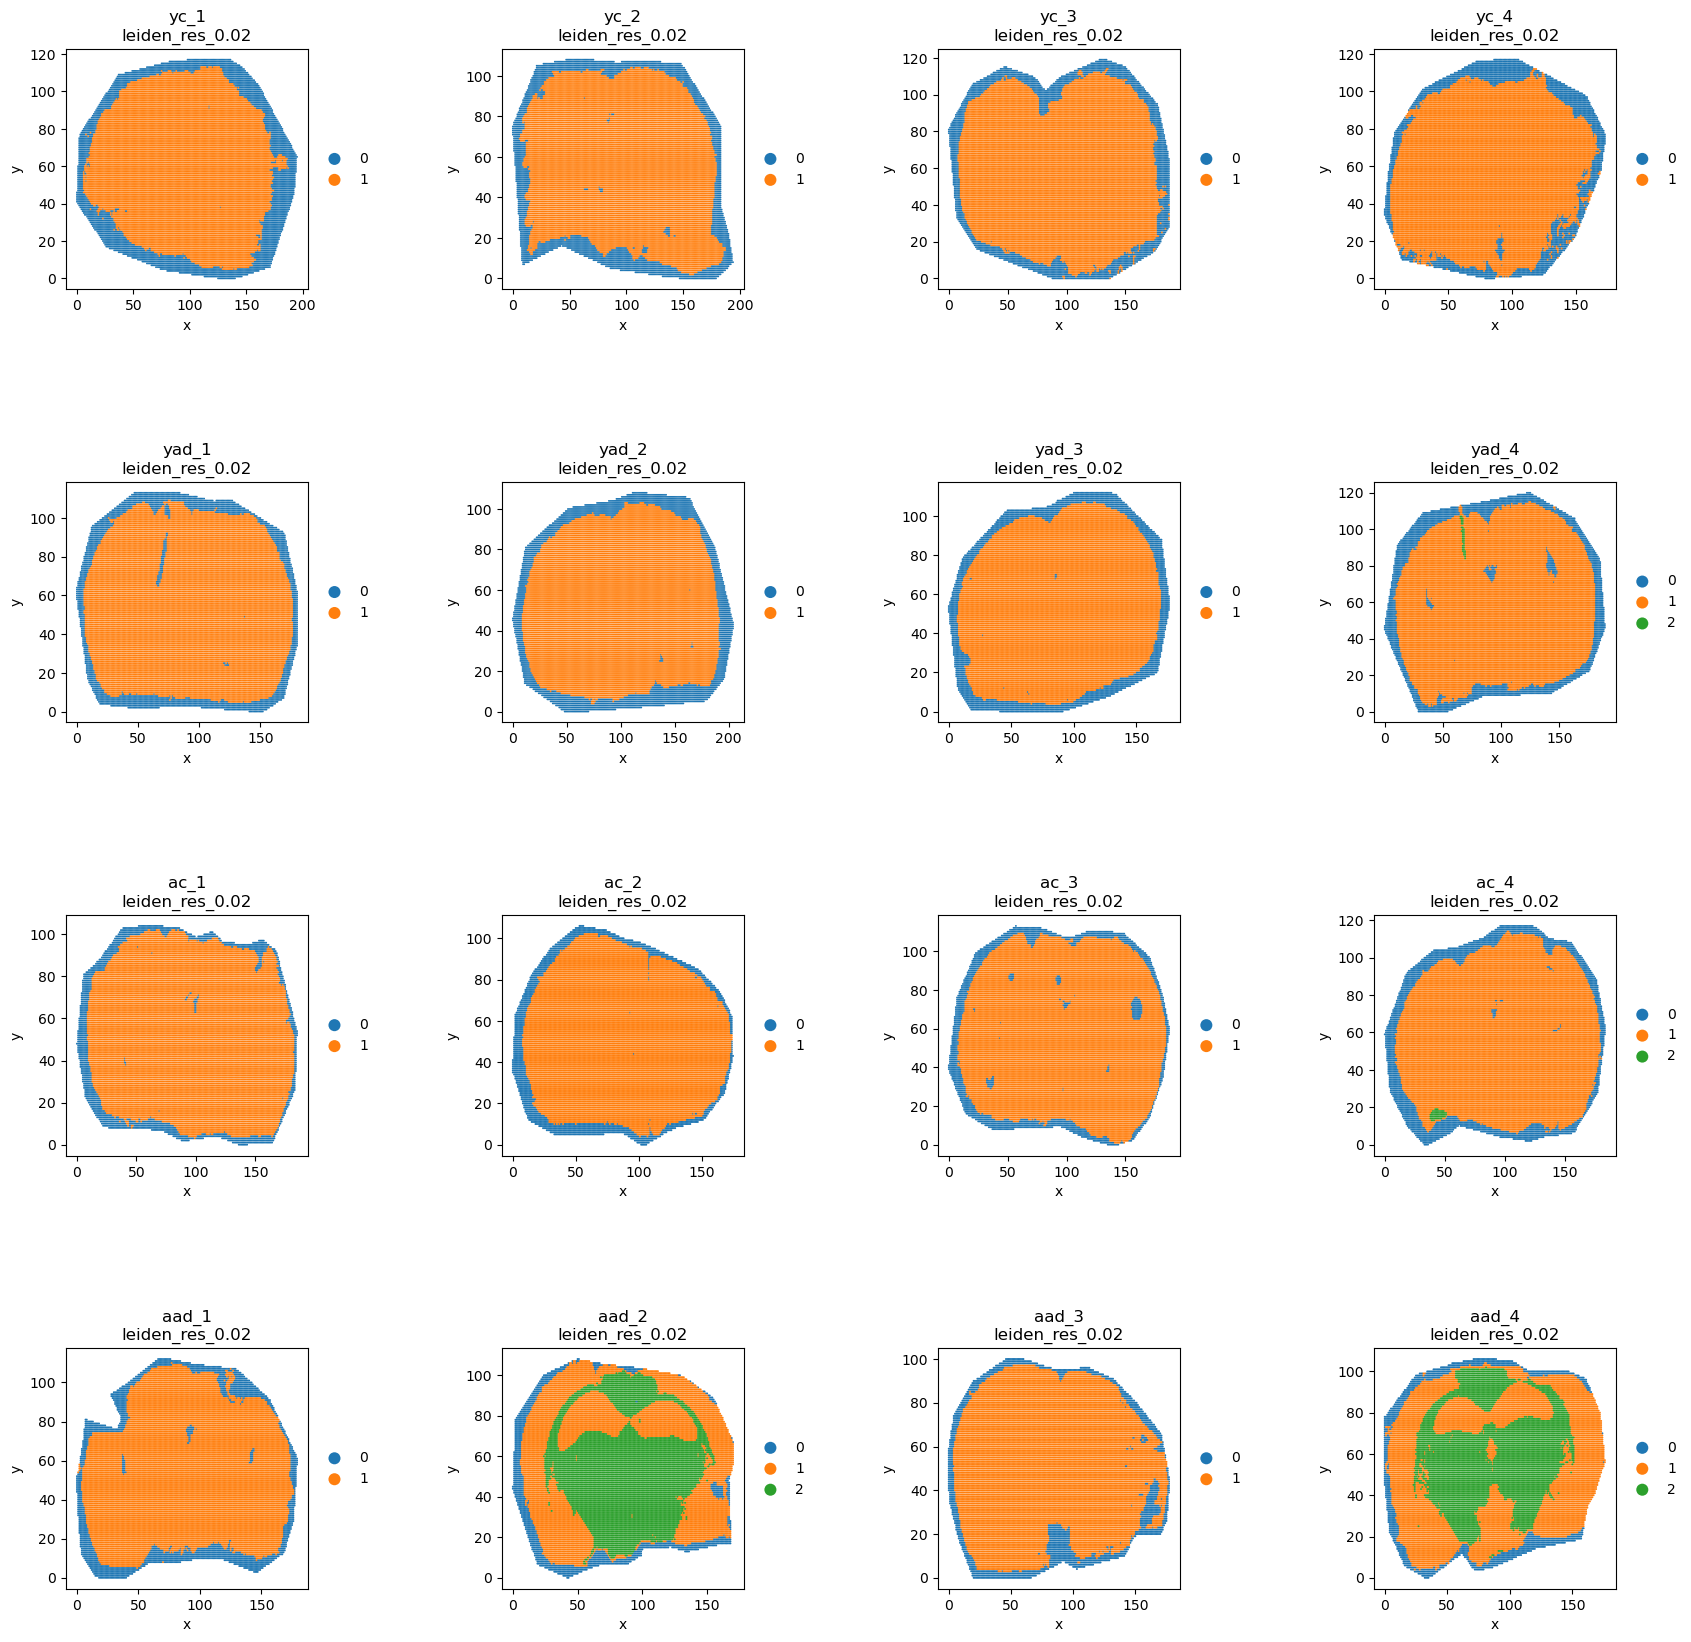

In [35]:
# Ensure spatial info exists
for sample in sample_list:
    if 'spatial' not in sample.obsm:
        sample.obsm['spatial'] = sample.obs[['x', 'y']].values

fig, axs = plt.subplots(4, 4, figsize=(20, 20))
axs = axs.flatten()  # Flatten to 1D array for easy indexing

for i in range(16):
    sample_name = sample_ids[i]

    # Plot scatter using the sample-specific column name
    sc.pl.scatter(
        sample_list[i],
        x='x',
        y='y',
        color='leiden_res_0.02',  # <-- Must be string, not a Series
        ax=axs[i],
        show=False
    )
    axs[i].set_title(f'{sample_name}\nleiden_res_0.02', fontsize=12)

plt.subplots_adjust(wspace=0.8, hspace=0.8)
#plt.savefig("Leiden_Scatter.png", dpi=600, bbox_inches='tight')
plt.show()

In [36]:
list_obs_leiden = []
for i in range(len(sample_list)): 
    list_obs_leiden.append(sample_list[i].obs['leiden_res_0.02'])

In [37]:
# Your list of sample IDs (also used as keys in the dictionary)
aad_1 = sc.read_h5ad(os.path.join(input_folder, "AFM_AD_1_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
aad_2 = sc.read_h5ad(os.path.join(input_folder, "AFM_AD_2_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
aad_3 = sc.read_h5ad(os.path.join(input_folder, "AFM_AD_3_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
aad_4 = sc.read_h5ad(os.path.join(input_folder, "AFM_AD_4_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
ac_1 = sc.read_h5ad(os.path.join(input_folder, "AFM_C_1_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
ac_2 = sc.read_h5ad(os.path.join(input_folder, "AFM_C_2_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
ac_3 = sc.read_h5ad(os.path.join(input_folder, "AFM_C_3_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
ac_4 = sc.read_h5ad(os.path.join(input_folder, "AFM_C_4_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
yad_1 = sc.read_h5ad(os.path.join(input_folder, "YFM_AD_1_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
yad_2 = sc.read_h5ad(os.path.join(input_folder, "YFM_AD_2_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
yad_3 = sc.read_h5ad(os.path.join(input_folder, "YFM_AD_3_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
yad_4 = sc.read_h5ad(os.path.join(input_folder, "YFM_AD_4_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
yc_1 = sc.read_h5ad(os.path.join(input_folder, "YFM_C_1_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
yc_2 = sc.read_h5ad(os.path.join(input_folder, "YFM_C_2_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
yc_3 = sc.read_h5ad(os.path.join(input_folder, "YFM_C_3_peaks_0.00001_top1000_9w_3p_5points.h5ad"))
yc_4 = sc.read_h5ad(os.path.join(input_folder, "YFM_C_4_peaks_0.00001_top1000_9w_3p_5points.h5ad"))

In [38]:
sample_list = [
    yc_1, yc_2, yc_3, yc_4,
    yad_1, yad_2, yad_3, yad_4,
    ac_1, ac_2, ac_3, ac_4,
    aad_1, aad_2, aad_3, aad_4
]

sample_ids = [
    "yc_1", "yc_2", "yc_3", "yc_4",
    "yad_1", "yad_2", "yad_3", "yad_4",
    "ac_1", "ac_2", "ac_3", "ac_4",
    "aad_1", "aad_2", "aad_3", "aad_4"
]

# Map sample ID → AnnData object
sample_map = dict(zip(sample_ids, sample_list))

In [39]:
for i in range(len(sample_list)): 
    sample_list[i].obs['leiden_res_0.02'] = list_obs_leiden[i]

In [40]:

# Drop clusters '1' and '2' from adata
for i in range(len(sample_list)):
    sample_list[i] = sample_list[i][~sample_list[i].obs['leiden_res_0.02'].isin(['0'])].copy()

sample_list[7] = sample_list[7][~sample_list[7].obs['leiden_res_0.02'].isin(['2'])].copy()

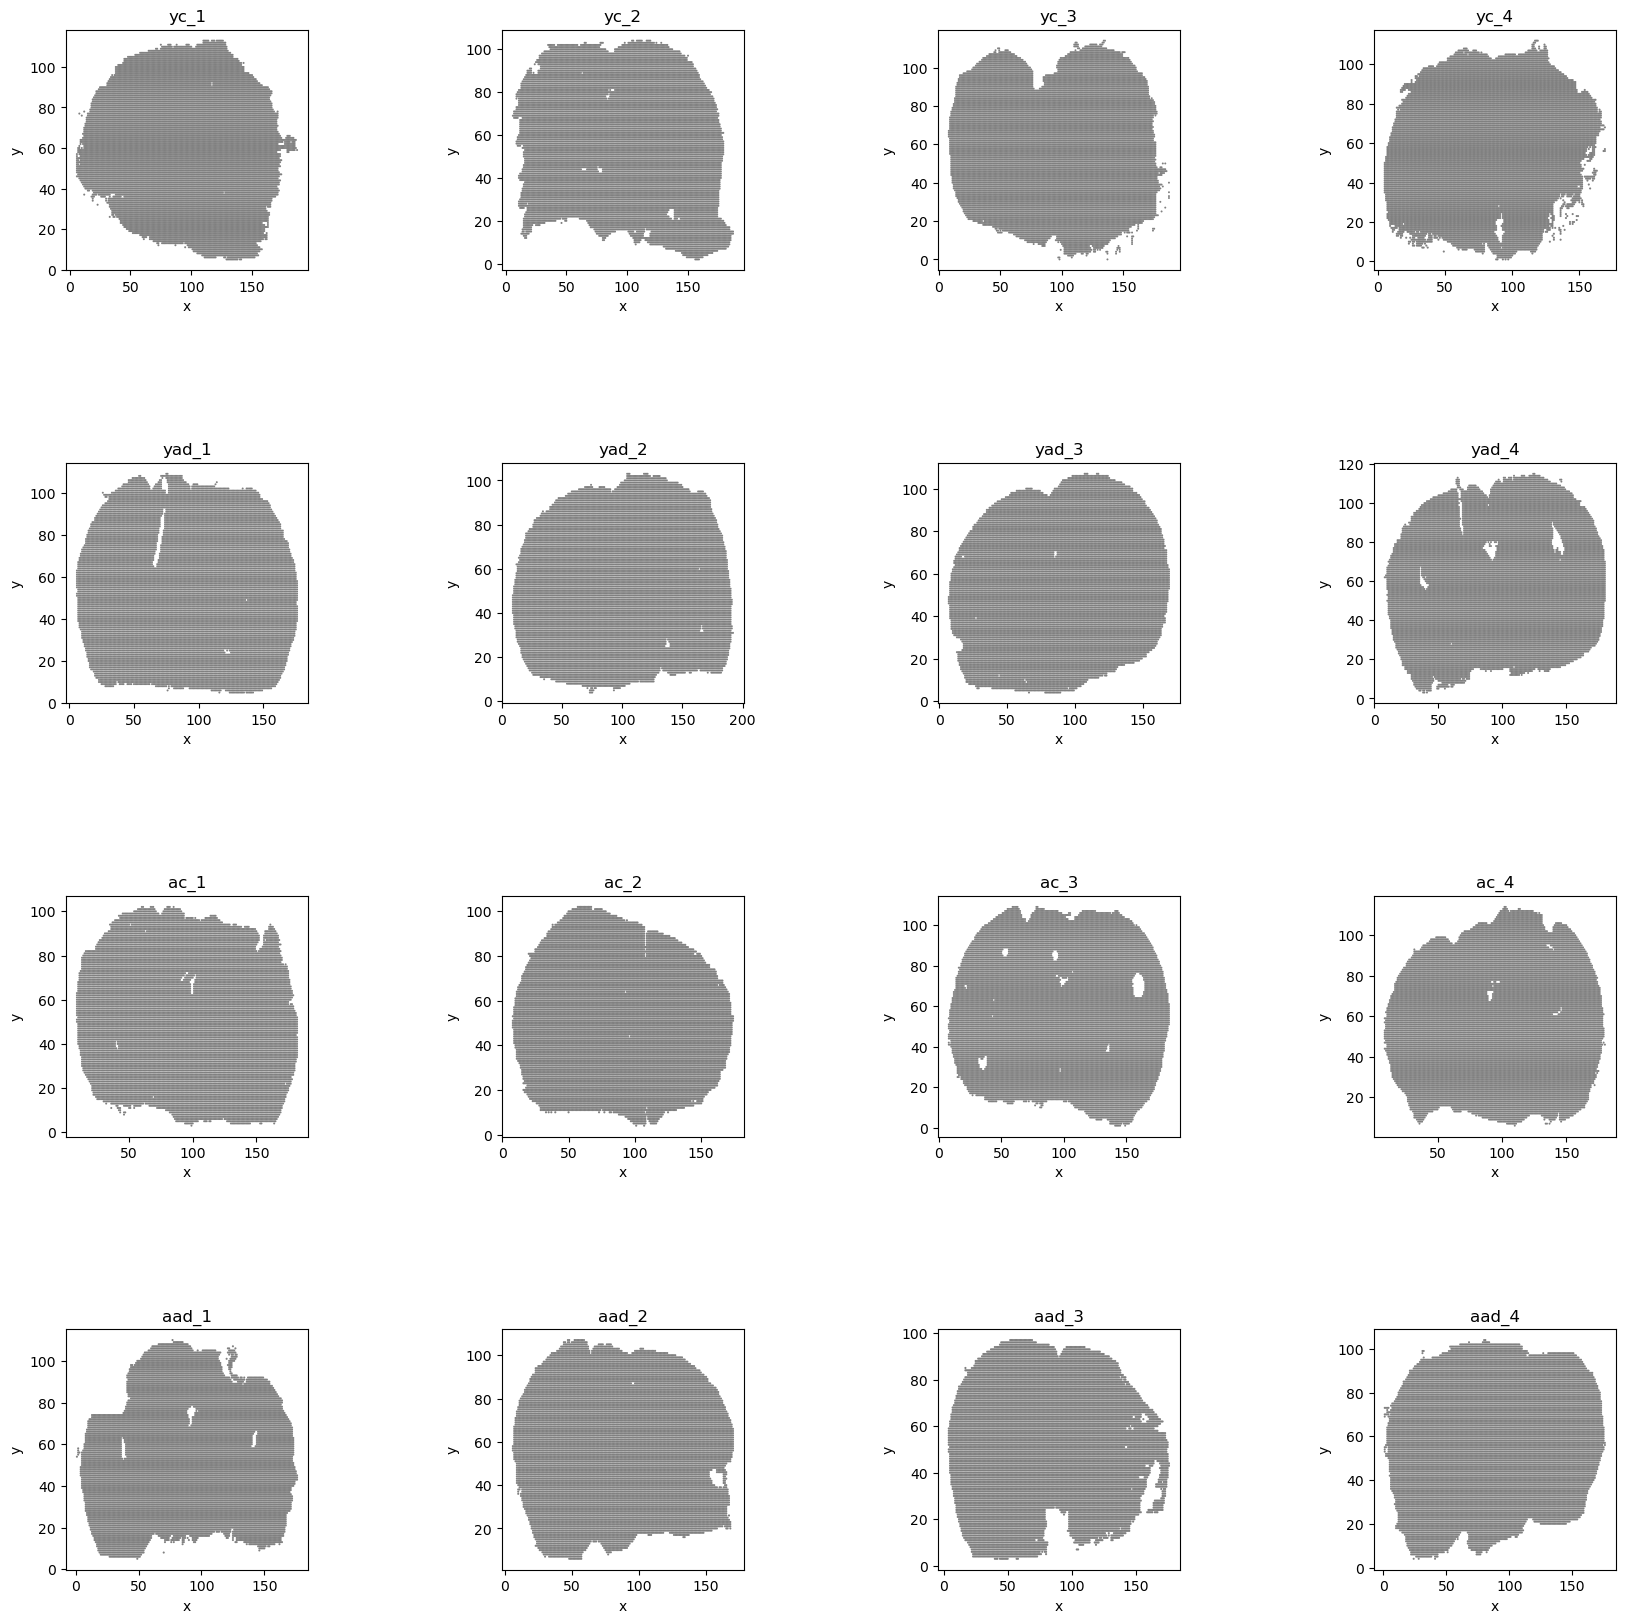

In [41]:
# Ensure spatial info exists
for sample in sample_list:
    if 'spatial' not in sample.obsm:
        sample.obsm['spatial'] = sample.obs[['x', 'y']].values

fig, axs = plt.subplots(4, 4, figsize=(20, 20))
axs = axs.flatten()  # Flatten to 1D array for easy indexing

for i in range(16):
    sample_name = sample_ids[i]

    # Plot scatter using the sample-specific column name
    sc.pl.scatter(
        sample_list[i],
        x='x',
        y='y',
        ax=axs[i],
        show=False
    )
    axs[i].set_title(f'{sample_name}', fontsize=12)

plt.subplots_adjust(wspace=0.8, hspace=0.8)
#plt.savefig("Leiden_Scatter.png", dpi=600, bbox_inches='tight')
plt.show()

In [42]:
for i, sample in enumerate(sample_list):
    # Save each sample to a new h5ad file
    output_file = os.path.join(filtered_h5ad_output_folder, f"{sample_ids[i]}_filtered.h5ad")
    sample.write(output_file)
    print(f"Saved filtered data for {sample_ids[i]} to {output_file}")

Saved filtered data for yc_1 to /home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filtered/yc_1_filtered.h5ad
Saved filtered data for yc_2 to /home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filtered/yc_2_filtered.h5ad
Saved filtered data for yc_3 to /home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filtered/yc_3_filtered.h5ad
Saved filtered data for yc_4 to /home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filtered/yc_4_filtered.h5ad


Saved filtered data for yad_1 to /home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filtered/yad_1_filtered.h5ad
Saved filtered data for yad_2 to /home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filtered/yad_2_filtered.h5ad
Saved filtered data for yad_3 to /home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filtered/yad_3_filtered.h5ad
Saved filtered data for yad_4 to /home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filtered/yad_4_filtered.h5ad
Saved filtered data for ac_1 to /home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filtered/ac_1_filtered.h5ad
Saved filtered data for ac_2 to /home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filtered/ac_2_filtered.h5ad
Saved filtered data for ac_3 to /home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filtered/ac_3_filtered.h5ad
Saved filtered data for ac_4 to /home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filt